# Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# DataSet Load

In [ ]:
df = pd.read_csv('creditcard.csv')
print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (17546, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17546 entries, 0 to 17545
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    17546 non-null  float64
 1   V1      17546 non-null  float64
 2   V2      17546 non-null  float64
 3   V3      17546 non-null  float64
 4   V4      17546 non-null  float64
 5   V5      17546 non-null  float64
 6   V6      17546 non-null  float64
 7   V7      17546 non-null  float64
 8   V8      17546 non-null  float64
 9   V9      17546 non-null  float64
 10  V10     17546 non-null  float64
 11  V11     17546 non-null  float64
 12  V12     17546 non-null  float64
 13  V13     17546 non-null  float64
 14  V14     17546 non-null  float64
 15  V15     17546 non-null  float64
 16  V16     17546 non-null  float64
 17  V17     17546 non-null  float64
 18  V18     17546 non-null  float64
 19  V19     17546 non-null  float64
 20  V20     17546 non-null  float64
 21  V21     17546 non-null  float64
 22

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,"17,546.0000","17,546.0000","17,546.0000","17,546.0000","17,546.0000","17,546.0000","17,546.0000","17,546.0000","17,546.0000","17,546.0000",...,"17,546.0000","17,546.0000","17,546.0000","17,546.0000","17,546.0000","17,546.0000","17,546.0000","17,546.0000","17,546.0000","17,546.0000"
mean,"13,587.5387",-0.2522,0.2657,0.7773,0.2965,-0.1400,0.1015,-0.1490,0.0129,0.7544,...,-0.0559,-0.1539,-0.0374,0.0140,0.1188,0.0367,0.0148,0.0067,67.2124,0.0046
std,"9,725.0835",1.9014,1.5132,1.7742,1.4823,1.4289,1.3311,1.3479,1.3255,1.2738,...,0.8315,0.6296,0.5296,0.5880,0.4392,0.5388,0.3966,0.2495,188.6765,0.0678
min,0.0000,-30.5524,-40.9789,-31.1037,-5.1726,-32.0921,-23.4967,-26.5481,-23.6325,-7.1751,...,-11.4684,-8.5936,-26.7511,-2.6878,-7.4957,-1.3386,-8.5676,-3.5753,0.0000,0.0000
25%,"3,766.0000",-0.9642,-0.2976,0.3386,-0.6268,-0.7225,-0.6519,-0.5972,-0.1767,-0.0782,...,-0.2639,-0.5599,-0.1729,-0.3314,-0.1424,-0.3469,-0.0721,-0.0122,5.4000,0.0000
50%,"11,951.0000",-0.3121,0.2416,0.9216,0.2348,-0.1884,-0.1692,-0.0750,0.0197,0.7525,...,-0.1212,-0.1229,-0.0454,0.0631,0.1568,-0.0278,0.0023,0.0182,15.9500,0.0000
75%,"23,107.2500",1.1626,0.8821,1.5580,1.1609,0.3509,0.4967,0.4487,0.2730,1.4942,...,0.0376,0.2448,0.0738,0.3974,0.3964,0.3463,0.0994,0.0771,56.2575,0.0000
max,"28,804.0000",1.9605,16.7134,4.1017,11.9275,34.0993,21.3931,34.3032,20.0072,10.3929,...,22.6149,4.5345,13.8762,3.6955,5.5251,3.5173,8.2544,4.8608,"7,712.4300",1.0000


# Data Preprocessing

In [ ]:
#missing values in the dataset
print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if any(missing_values > 0) else "No missing values found!")

#ensure all features are numeric
print("\nDataset Info Summary:")
df.info()

Missing values per column:
No missing values found!

Dataset Info Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17546 entries, 0 to 17545
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    17546 non-null  float64
 1   V1      17546 non-null  float64
 2   V2      17546 non-null  float64
 3   V3      17546 non-null  float64
 4   V4      17546 non-null  float64
 5   V5      17546 non-null  float64
 6   V6      17546 non-null  float64
 7   V7      17546 non-null  float64
 8   V8      17546 non-null  float64
 9   V9      17546 non-null  float64
 10  V10     17546 non-null  float64
 11  V11     17546 non-null  float64
 12  V12     17546 non-null  float64
 13  V13     17546 non-null  float64
 14  V14     17546 non-null  float64
 15  V15     17546 non-null  float64
 16  V16     17546 non-null  float64
 17  V17     17546 non-null  float64
 18  V18     17546 non-null  float64
 19  V19     17546 non-null  float64
 2

In [ ]:
# Initialize the RobustScaler or StandardScaler
scaler = StandardScaler()

# Scale the 'Amount' feature and create a new column
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])

# Drop the original 'Amount' and 'Time' columns
# 'Time' is usually dropped as it just indicates seconds elapsed since the first transaction
X = df.drop(columns=['Time', 'Amount', 'Class'])
y = df['Class']

print("Features after scaling 'Amount' and dropping unnecessary columns:")


Features after scaling 'Amount' and dropping unnecessary columns:


# Splits

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train Shape: {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape: {X_test.shape} | y_test Shape: {y_test.shape}")

# Verify the class distribution in the splits
print("\nFraud percentage in Training Set:")
print(y_train.value_counts(normalize=True) * 100)
print("\nFraud percentage in Testing Set:")
print(y_test.value_counts(normalize=True) * 100)

X_train Shape: (14036, 29) | y_train Shape: (14036,)
X_test Shape: (3510, 29) | y_test Shape: (3510,)

Fraud percentage in Training Set:
Class
0   99.5369
1    0.4631
Name: proportion, dtype: float64

Fraud percentage in Testing Set:
Class
0   99.5442
1    0.4558
Name: proportion, dtype: float64


In [ ]:
# Install imbalanced-learn if not already available
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    !pip install imbalanced-learn
    from imblearn.over_sampling import SMOTE

# Apply SMOTE only on the training data to prevent data leakage
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE - Legitimate (0): {sum(y_train == 0)}, Fraudulent (1): {sum(y_train == 1)}")
print(f"After SMOTE  - Legitimate (0): {sum(y_train_resampled == 0)}, Fraudulent (1): {sum(y_train_resampled == 1)}")

Before SMOTE - Legitimate (0): 13971, Fraudulent (1): 65
After SMOTE  - Legitimate (0): 13971, Fraudulent (1): 13971


# Algorithm Implementation

In [ ]:
if 'model_predictions' not in locals():
    model_predictions = {}
if 'evaluation_results' not in locals():
    evaluation_results = {}

### Logistic Regression

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr_model.predict(X_test)
model_predictions["Logistic Regression"] = y_pred_lr

evaluation_results["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1-Score": f1_score(y_test, y_pred_lr)
}

### K-Nearest Neighbors (KNN)

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_resampled, y_train_resampled)

y_pred_knn = knn_model.predict(X_test)
model_predictions["K-Nearest Neighbors"] = y_pred_knn

evaluation_results["K-Nearest Neighbors"] = {
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1-Score": f1_score(y_test, y_pred_knn)
}

### Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

y_pred_dt = dt_model.predict(X_test)
model_predictions["Decision Tree"] = y_pred_dt

evaluation_results["Decision Tree"] = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1-Score": f1_score(y_test, y_pred_dt)
}

### Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test)
model_predictions["Random Forest"] = y_pred_rf

evaluation_results["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf)
}

# Comparison Table

In [ ]:
df_comparison = pd.DataFrame(evaluation_results).T
pd.options.display.float_format = '{:,.4f}'.format

df_comparison

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.9889,0.2745,0.8750,0.4179
K-Nearest Neighbors,0.9977,0.7000,0.8750,0.7778
Decision Tree,0.9986,0.8235,0.8750,0.8485
Random Forest,0.9989,0.8750,0.8750,0.8750


# Confusion Matrix

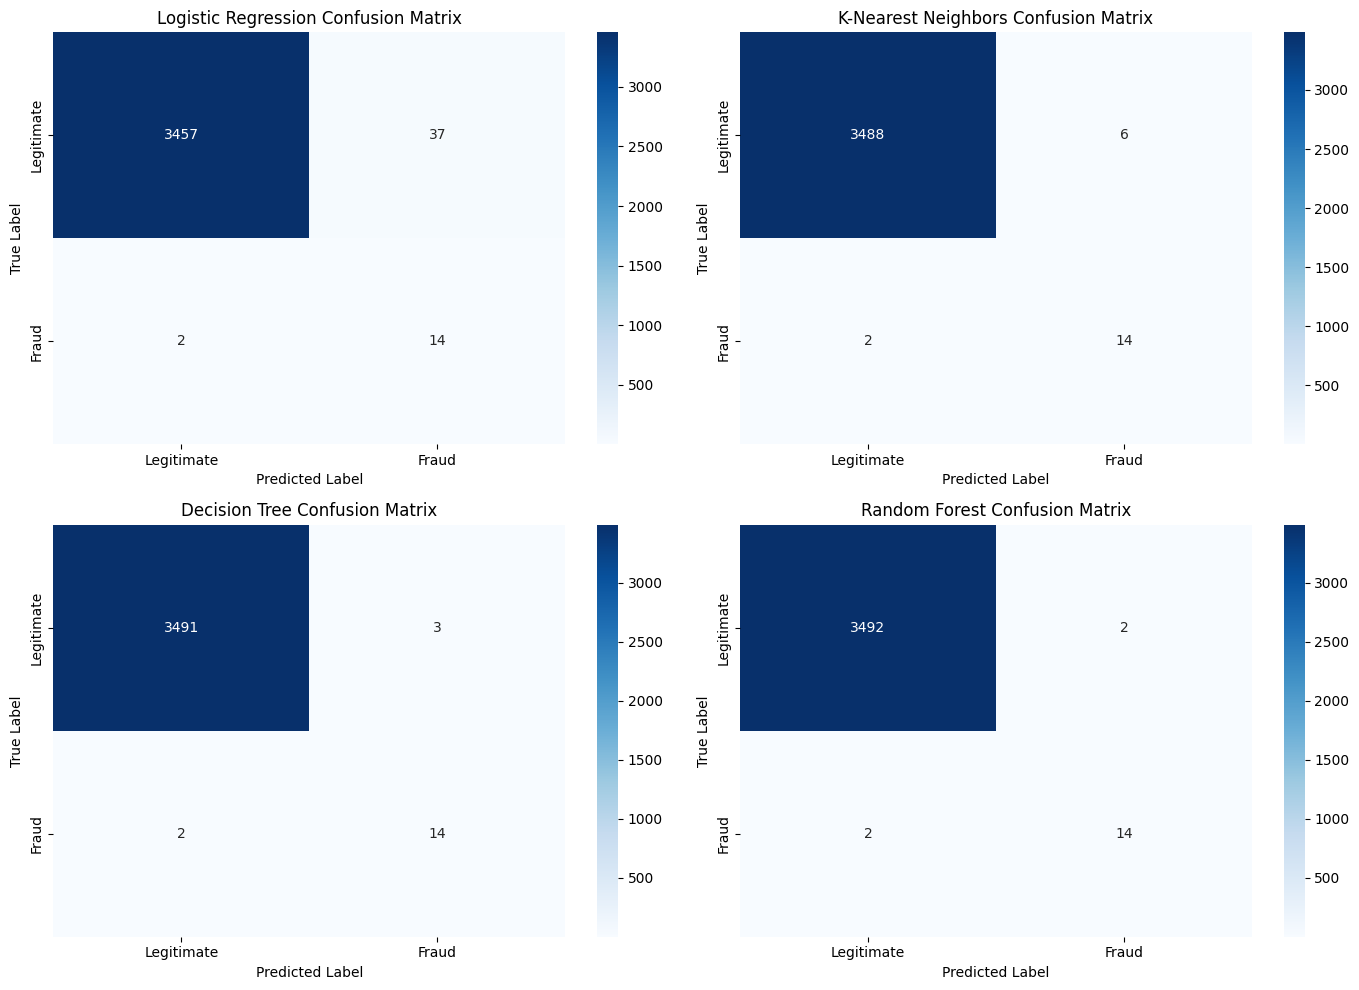

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (name, y_pred) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Roc Curves

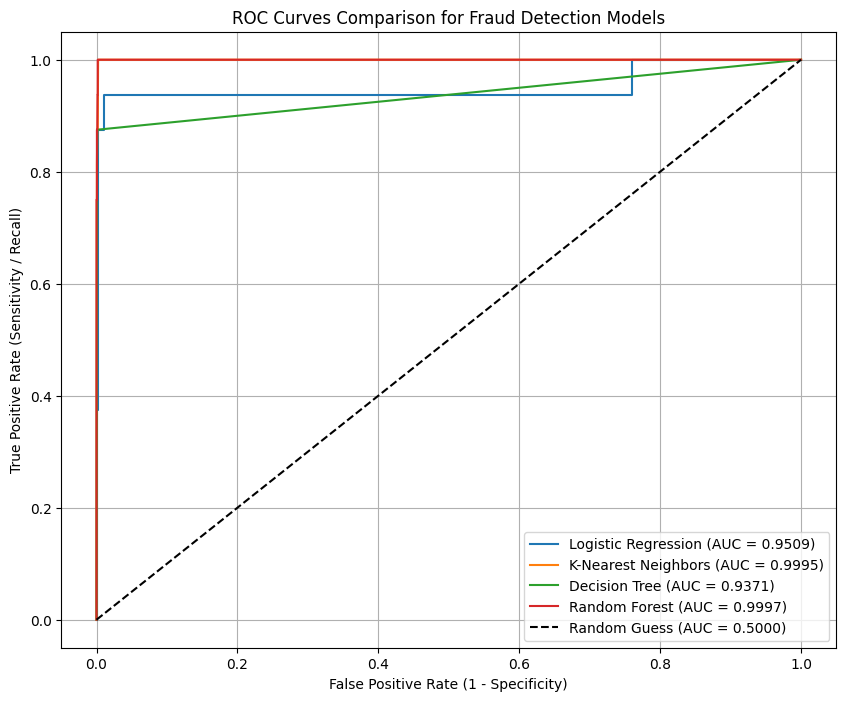

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Create a dictionary of all trained models
models = {
    "Logistic Regression": lr_model,
    "K-Nearest Neighbors": knn_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:

        if hasattr(model, "decision_function"):
            y_pred_proba = model.decision_function(X_test)
        else:
            y_pred_proba = model.predict(X_test)

    #AUC Score
    auc_score = roc_auc_score(y_test, y_pred_proba)

    #ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curves Comparison for Fraud Detection Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()